# ОНПД. Лабораторна робота №4

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
mydata = pd.read_csv("train.csv")

In [3]:
mydata.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [4]:
mydata.tail()

,x,y
695,58.0,58.595006
696,93.0,94.625094
697,82.0,88.603770
698,66.0,63.648685
699,97.0,94.975266


In [5]:
mydata.shape

(700, 2)

In [6]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [7]:
mydata.dropna(inplace=True)

In [8]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       699 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 16.4 KB


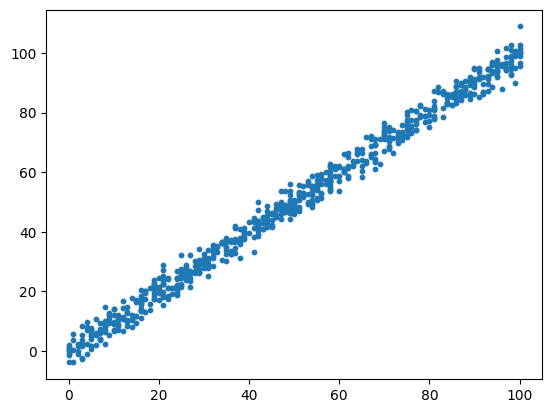

In [9]:
plt.scatter(mydata["x"],mydata["y"],s=10)

In [10]:
X = mydata["x"].values.reshape(-1,1)
Y = mydata["y"].values.reshape(-1,1)

In [11]:
mydata["x"].head(10)

0    24.0
1    50.0
2    15.0
3    38.0
4    87.0
5    36.0
6    12.0
7    81.0
8    25.0
9     5.0
Name: x, dtype: float64

In [12]:
X[0:10]

array([[24.],
       [50.],
       [15.],
       [38.],
       [87.],
       [36.],
       [12.],
       [81.],
       [25.],
       [ 5.]])

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_cv, y_train, y_cv = train_test_split(X,Y,test_size=0.3, random_state=143)

In [16]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
some_data = X_train[:5]
some_labels = y_train[:5]
print("Predictions: " ,lin_reg.predict(some_data))
print("Labels:",some_labels)

Predictions:  [[33.76440245]
 [63.88885236]
 [17.69802917]
 [16.69388084]
 [21.71462249]]
Labels: [[30.48882921]
 [66.7346608 ]
 [21.21321959]
 [13.24991628]
 [18.56241391]]


In [17]:
from sklearn.metrics import mean_squared_error
predictions = lin_reg.predict(X_train)
mse = mean_squared_error(y_train, predictions)
rmse = np.sqrt(mse)
rmse

np.float64(2.7396101133706083)

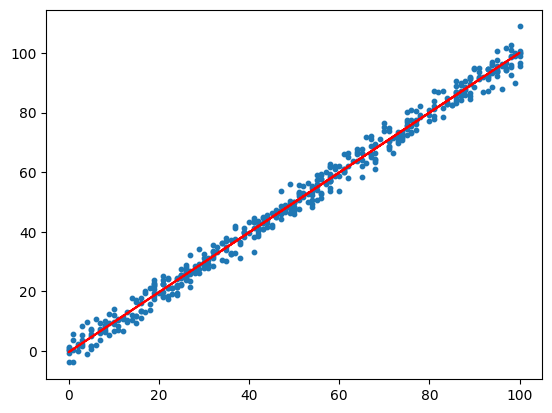

In [18]:
plt.scatter(X_train, y_train,s=10)
plt.plot(X_train, predictions, color='red')
plt.show()

In [19]:
cv_predictions = lin_reg.predict(X_cv)
cv_mse = mean_squared_error(y_cv, cv_predictions)
cv_rmse = np.sqrt(cv_mse)
cv_rmse

np.float64(2.962299120833467)

In [20]:
data_test = pd.read_csv("linear_reg/test.csv")
X_test = mydata["x"].values.reshape(-1,1)
y_test = mydata["y"].values.reshape(-1,1)

FileNotFoundError: [Errno 2] No such file or directory: 'linear_reg/test.csv'

In [21]:
final_predictions = lin_reg.predict(X_test)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

NameError: name 'X_test' is not defined

In [ ]:
from sklearn.metrics import r2_score
score=r2_score(y_test, final_predictions)
score

In [ ]:
plt.figure(figsize=(10.66,6))
plt.scatter(mydata["x"],mydata["y"],s=10)
plt.savefig("linear_reg/raw_data.jpg")

In [ ]:
plt.figure(figsize=(10.66,6))
plt.scatter(mydata["x"],mydata["y"],s=10)
plt.plot(X_train, predictions, color='red')
plt.savefig("linear_reg/final_graph.jpg")